# Unsupervised analysis — DropSeq

Goal: discover structure in the DropSeq data **without** using the
Hypo/Norm labels, then compare what we found with the labels to decide
whether hypoxia is the dominant transcriptional axis.

Pipeline (one per cell line):

1. Wrap the expression matrix as a `scanpy.AnnData` object.
2. Scale → PCA → nearest-neighbour graph → UMAP.
3. **Leiden clustering** at several resolutions; pick the resolution that
   maximises the **silhouette score** in PCA space.
4. **KMeans** for `k = 2..6` as a sanity check; pick the `k` with the
   best silhouette.
5. Compare the best clustering against the ground-truth condition with
   Adjusted Rand Index (ARI) and Normalised Mutual Information (NMI).

In [17]:
import sys
from pathlib import Path

# put the project root on sys.path (notebook 04 imports helpers from src/)
sys.path.insert(0, str(Path.cwd().parents[1]))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid")
RNG = 42

In [18]:
import anndata as ad
import scanpy as sc
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import KMeans

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=80, facecolor="white")


def to_anndata(expr, labels=None, dataset=""):
    # wrap a (cells x genes) frame as AnnData for scanpy
    adata = ad.AnnData(
        X=expr.values.astype(np.float32),
        obs=pd.DataFrame(index=expr.index.astype(str)),
        var=pd.DataFrame(index=expr.columns.astype(str)),
    )
    adata.obs_names_make_unique()
    if labels is not None:
        adata.obs["condition"] = pd.Categorical(labels.values, categories=["Norm", "Hypo"])
    if dataset:
        adata.uns["dataset"] = dataset
    return adata


def run_scanpy_pipeline(adata, n_pcs=30, n_neighbors=15, random_state=42):
    # data is already normalised and cut to 3000 HVGs, so no normalize_total /
    # log1p / highly_variable_genes here -- just scale, PCA, kNN graph, UMAP.
    sc.pp.scale(adata, max_value=10)
    sc.tl.pca(adata, n_comps=n_pcs, random_state=random_state)
    sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=n_pcs, random_state=random_state)
    sc.tl.umap(adata, random_state=random_state)
    return adata


def silhouette_sweep_leiden(adata, resolutions, random_state=42):
    # run Leiden at each resolution, score the partition by silhouette in PCA space
    rows = []
    X_pca = adata.obsm["X_pca"]
    for res in resolutions:
        key = f"leiden_r{res:.2f}"
        sc.tl.leiden(
            adata,
            resolution=res,
            random_state=random_state,
            key_added=key,
            flavor="igraph",
            n_iterations=2,
            directed=False,
        )
        labels = adata.obs[key].astype(int).values
        n_clusters = len(np.unique(labels))
        sil = silhouette_score(X_pca, labels) if n_clusters > 1 else np.nan
        rows.append({"resolution": res, "n_clusters": n_clusters, "silhouette": sil, "key": key})
    return pd.DataFrame(rows)


def silhouette_sweep_kmeans(adata, ks, random_state=42):
    rows = []
    X_pca = adata.obsm["X_pca"]
    for k in ks:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10).fit(X_pca)
        sil = silhouette_score(X_pca, km.labels_)
        adata.obs[f"kmeans_k{k}"] = pd.Categorical(km.labels_.astype(str))
        rows.append({"k": k, "silhouette": sil})
    return pd.DataFrame(rows)


def label_agreement(adata, cluster_key):
    # how well does this clustering line up with the true Hypo/Norm labels?
    truth = adata.obs["condition"].astype(str).values
    pred = adata.obs[cluster_key].astype(str).values
    ari = adjusted_rand_score(truth, pred)
    nmi = normalized_mutual_info_score(truth, pred)
    contingency = pd.crosstab(adata.obs["condition"], adata.obs[cluster_key])
    return ari, nmi, contingency

/var/folders/nr/mb9t16753gl29cqg5ry9kft00000gn/T/ipykernel_70422/2509773607.py:7: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=80, facecolor="white")


In [19]:
CELL_LINES = ["MCF7", "HCC1806"]

## 1 — Build AnnData for both cell lines

In [20]:
adatas = {}
for cl in CELL_LINES:
    X, y = load_dropseq(cl, split="train")
    adatas[cl] = to_anndata(X, y, dataset=f"{cl}_DropSeq")
    print(f"{cl}: {adatas[cl]}")

NameError: name 'load_dropseq' is not defined

## 2 — Run the scanpy pipeline (PCA, neighbours, UMAP)

In [ ]:
for cl, a in adatas.items():
    run_scanpy_pipeline(a, n_pcs=30, n_neighbors=15)

/Users/gift/Projects/Python_projects/AI_Lab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


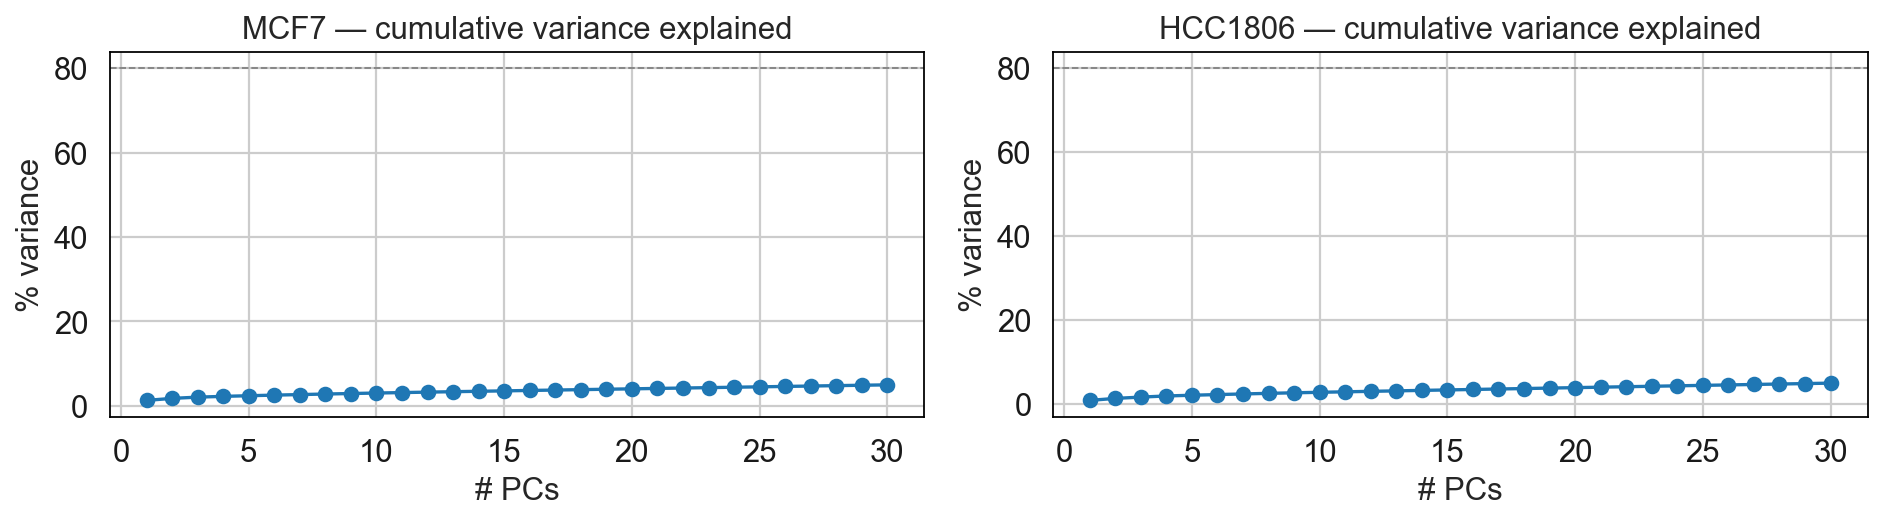

In [ ]:
# cumulative variance per PC, just to check 30 PCs is a sensible cut.
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, (cl, a) in zip(axes, adatas.items()):
    var = a.uns["pca"]["variance_ratio"]
    ax.plot(np.arange(1, len(var) + 1), np.cumsum(var) * 100, "o-")
    ax.axhline(80, ls="--", c="grey", lw=0.8)
    ax.set_title(f"{cl} — cumulative variance explained")
    ax.set_xlabel("# PCs")
    ax.set_ylabel("% variance")
plt.tight_layout()
plt.show()

## 3 — UMAP coloured by the (held-out) condition

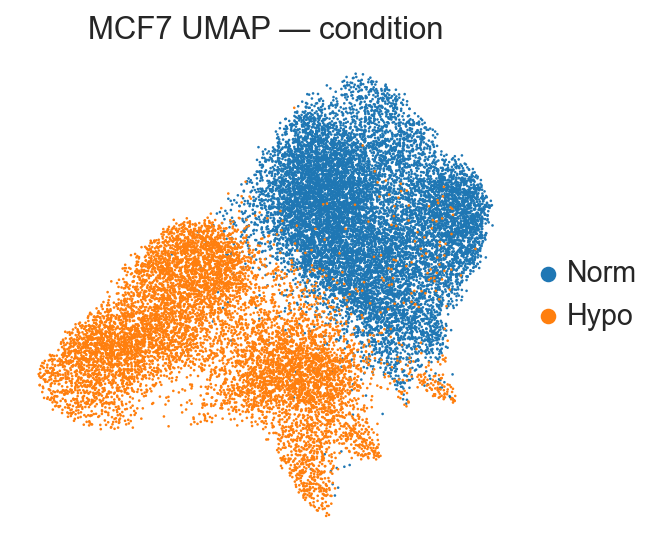

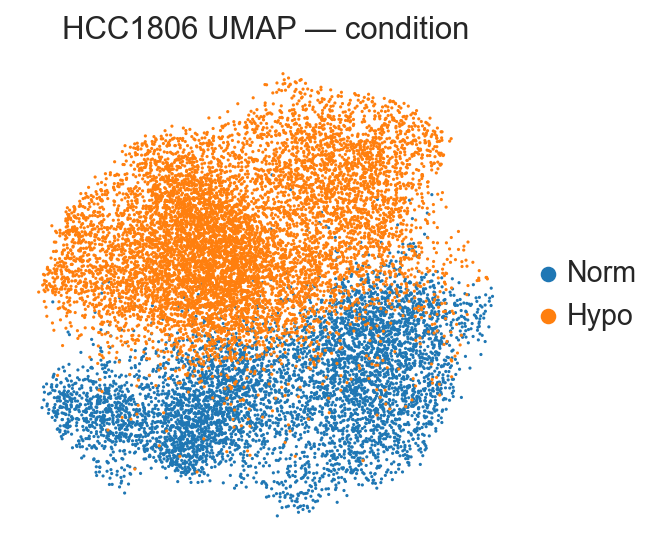

In [ ]:
for cl, a in adatas.items():
    sc.pl.umap(a, color="condition", title=f"{cl} UMAP — condition", frameon=False, show=True)

If Hypo and Norm cells separate visually, the **dominant axis of variation in
the data is hypoxia** — encouraging for the supervised step. If they overlap
heavily, hypoxia may share its signal with other technical or biological
factors (cell cycle, batch, plate position for DropSeq).

## 4 — Silhouette sweep: Leiden resolution

In [ ]:
leiden_results = {}
for cl, a in adatas.items():
    df = silhouette_sweep_leiden(a, resolutions=[0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 1.5])
    leiden_results[cl] = df
    print(f"\n{cl} Leiden sweep:")
    print(df.to_string(index=False))


MCF7 Leiden sweep:
 resolution  n_clusters  silhouette          key
        0.1           2    0.130417 leiden_r0.10
        0.2           2    0.130022 leiden_r0.20
        0.3           4    0.068277 leiden_r0.30
        0.5           5    0.116039 leiden_r0.50
        0.8           7    0.028642 leiden_r0.80
        1.0           9    0.011750 leiden_r1.00
        1.5          13   -0.000404 leiden_r1.50



HCC1806 Leiden sweep:
 resolution  n_clusters  silhouette          key
        0.1           1         NaN leiden_r0.10
        0.2           2    0.101014 leiden_r0.20
        0.3           3    0.078678 leiden_r0.30
        0.5           4    0.067003 leiden_r0.50
        0.8           6    0.038885 leiden_r0.80
        1.0           7    0.023839 leiden_r1.00
        1.5          12    0.001718 leiden_r1.50


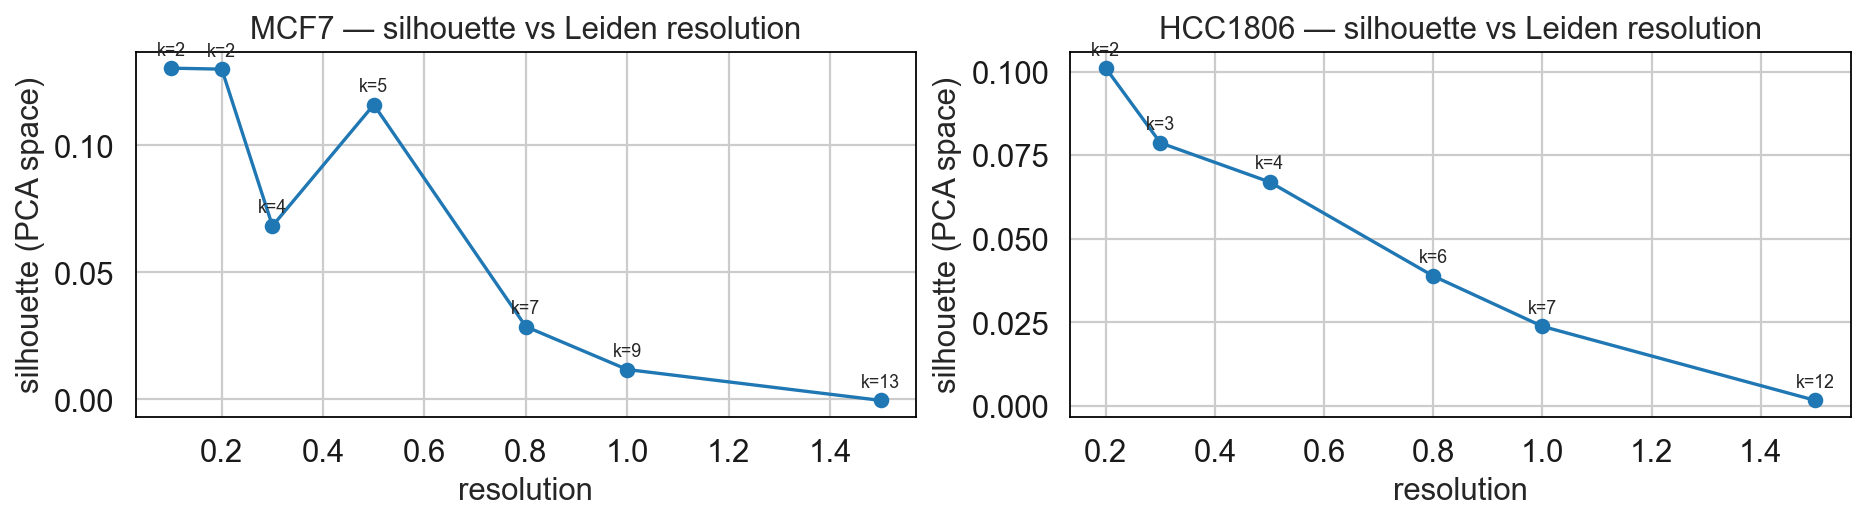

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, (cl, df) in zip(axes, leiden_results.items()):
    ax.plot(df["resolution"], df["silhouette"], "o-")
    for _, row in df.iterrows():
        ax.annotate(
            f"k={int(row['n_clusters'])}",
            (row["resolution"], row["silhouette"]),
            textcoords="offset points",
            xytext=(0, 6),
            fontsize=8,
            ha="center",
        )
    ax.set_title(f"{cl} — silhouette vs Leiden resolution")
    ax.set_xlabel("resolution")
    ax.set_ylabel("silhouette (PCA space)")
plt.tight_layout()
plt.show()

## 5 — Silhouette sweep: KMeans `k`

In [ ]:
kmeans_results = {}
for cl, a in adatas.items():
    df = silhouette_sweep_kmeans(a, ks=range(2, 7))
    kmeans_results[cl] = df
    print(f"\n{cl} KMeans sweep:")
    print(df.to_string(index=False))


MCF7 KMeans sweep:
 k  silhouette
 2    0.144982
 3    0.152333
 4    0.126261
 5    0.070769
 6    0.062263



HCC1806 KMeans sweep:
 k  silhouette
 2    0.106089
 3    0.083931
 4    0.074032
 5    0.069388
 6    0.069192


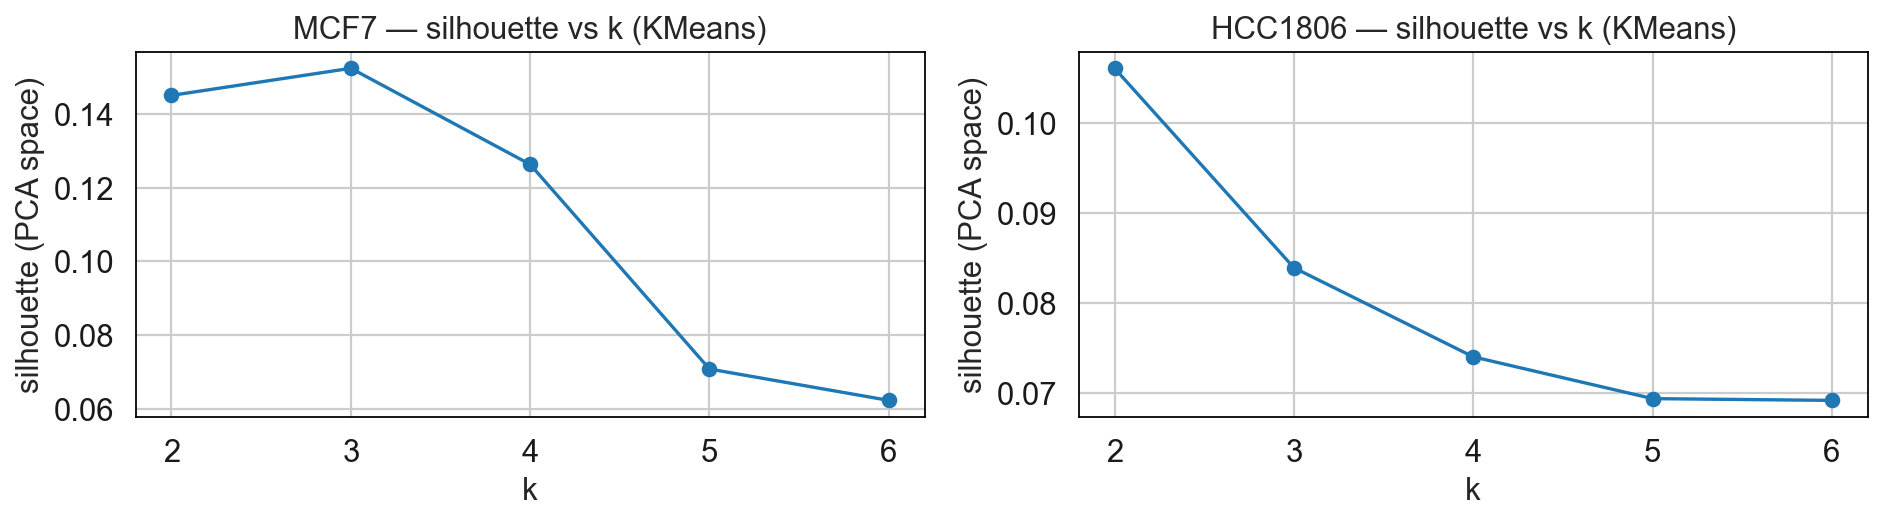

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, (cl, df) in zip(axes, kmeans_results.items()):
    ax.plot(df["k"], df["silhouette"], "o-")
    ax.set_title(f"{cl} — silhouette vs k (KMeans)")
    ax.set_xlabel("k")
    ax.set_ylabel("silhouette (PCA space)")
plt.tight_layout()
plt.show()

## 6 — Pick the best clustering and compare to ground truth

In [ ]:
# for each cell line take the leiden run with the best silhouette and
# the best KMeans, then see how each lines up with the true labels.
results = []
for cl, a in adatas.items():
    best = leiden_results[cl].loc[leiden_results[cl]["silhouette"].idxmax()]
    best_kmeans = kmeans_results[cl].loc[kmeans_results[cl]["silhouette"].idxmax()]
    ari_l, nmi_l, cont_l = label_agreement(a, best["key"])
    ari_k, nmi_k, cont_k = label_agreement(a, f"kmeans_k{int(best_kmeans['k'])}")
    print(f"\n=== {cl} ===")
    print(
        f"Best Leiden: res={best['resolution']:.2f}  k={int(best['n_clusters'])}  "
        f"silhouette={best['silhouette']:.3f}  ARI={ari_l:.3f}  NMI={nmi_l:.3f}"
    )
    print(cont_l)
    print(
        f"\nBest KMeans: k={int(best_kmeans['k'])}  silhouette={best_kmeans['silhouette']:.3f}  "
        f"ARI={ari_k:.3f}  NMI={nmi_k:.3f}"
    )
    print(cont_k)
    results.append(
        {
            "cell_line": cl,
            "leiden_res": best["resolution"],
            "leiden_k": int(best["n_clusters"]),
            "leiden_silhouette": best["silhouette"],
            "leiden_ari": ari_l,
            "leiden_nmi": nmi_l,
            "kmeans_k": int(best_kmeans["k"]),
            "kmeans_silhouette": best_kmeans["silhouette"],
            "kmeans_ari": ari_k,
            "kmeans_nmi": nmi_k,
        }
    )
pd.DataFrame(results)


=== MCF7 ===
Best Leiden: res=0.10  k=2  silhouette=0.130  ARI=0.880  NMI=0.802
leiden_r0.10      0     1
condition                
Norm          12530   175
Hypo            491  8430

Best KMeans: k=3  silhouette=0.152  ARI=0.282  NMI=0.321
kmeans_k3     0     1     2
condition                  
Norm         90  9142  3473
Hypo       5306  3116   499



=== HCC1806 ===
Best Leiden: res=0.20  k=2  silhouette=0.101  ARI=0.066  NMI=0.038
leiden_r0.20     0     1
condition               
Norm          3064  2719
Hypo          2706  6193

Best KMeans: k=2  silhouette=0.106  ARI=0.063  NMI=0.035
kmeans_k2     0     1
condition            
Norm       2962  2821
Hypo       2643  6256


,cell_line,leiden_res,leiden_k,leiden_silhouette,leiden_ari,leiden_nmi,kmeans_k,kmeans_silhouette,kmeans_ari,kmeans_nmi
0,MCF7,0.1,2,0.130417,0.880451,0.802331,3,0.152333,0.282438,0.320834
1,HCC1806,0.2,2,0.101014,0.066137,0.037935,2,0.106089,0.062958,0.034920


## 7 — UMAP coloured by best clustering

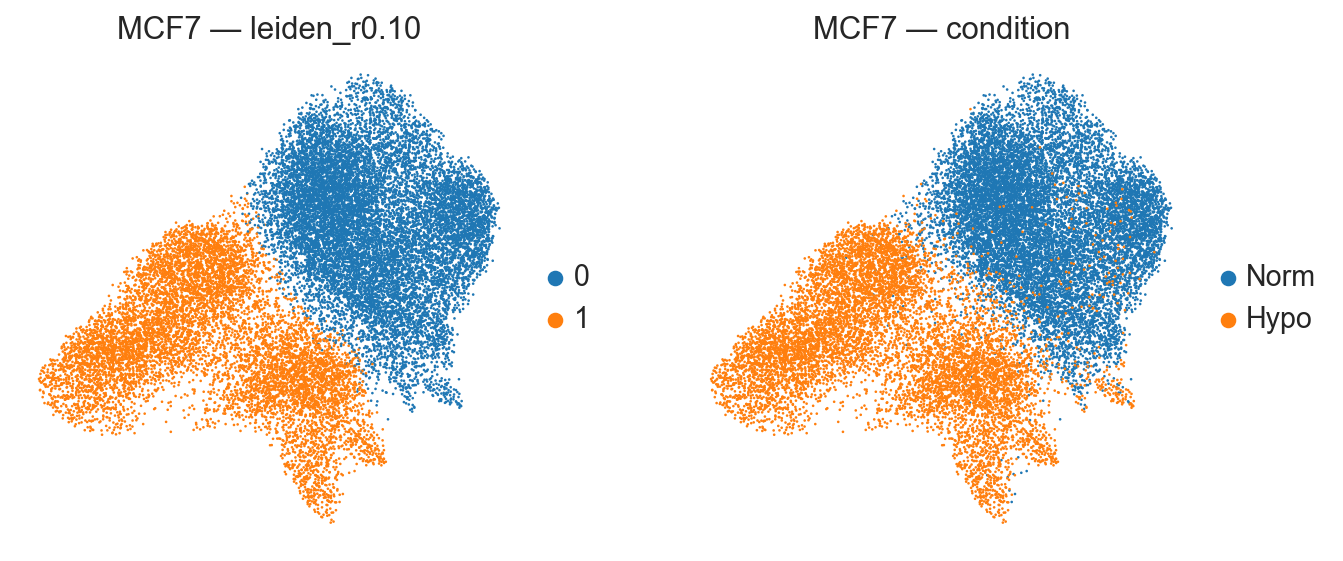

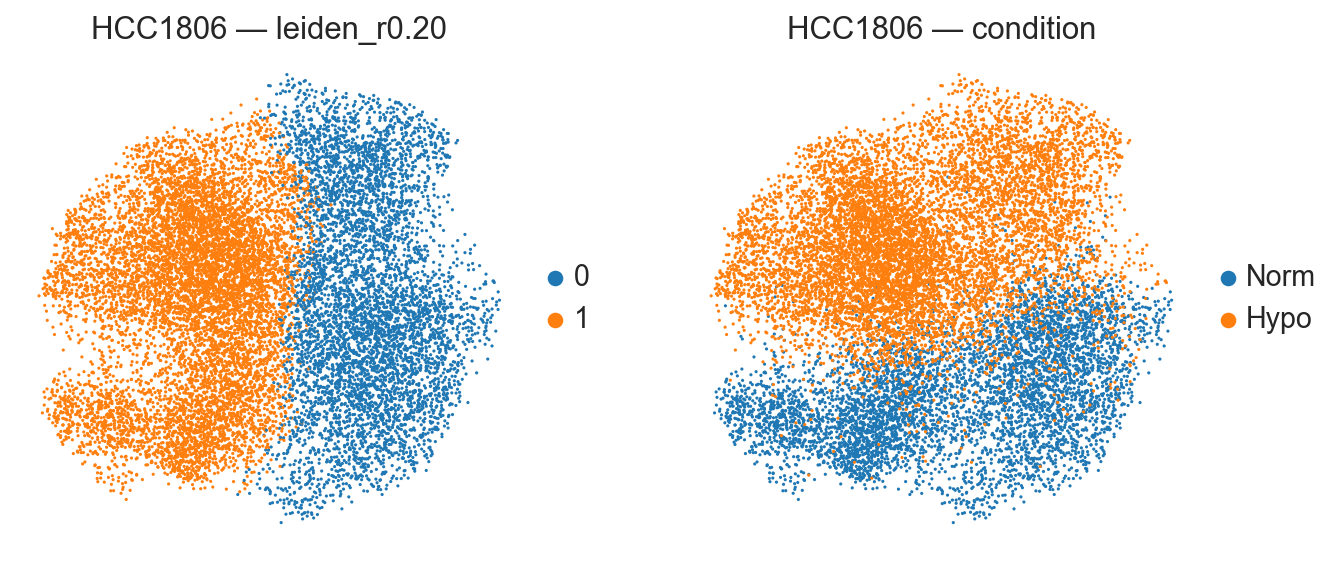

In [ ]:
for cl, a in adatas.items():
    best_key = leiden_results[cl].loc[leiden_results[cl]["silhouette"].idxmax(), "key"]
    sc.pl.umap(
        a, color=[best_key, "condition"], title=[f"{cl} — {best_key}", f"{cl} — condition"], frameon=False, show=True
    )

## 8 — Discussion

On DropSeq the same MCF7-vs-HCC1806 asymmetry appears, only harder.

**MCF7** still works. Leiden at res 0.10 gives 2 clusters (silhouette 0.13)
that recover the labels well: ARI 0.88, NMI 0.80. That is a notch below the
SmartSeq MCF7 result (ARI 0.98) -- DropSeq's shallow, dropout-heavy counts
blur the split a little -- but hypoxia is clearly the leading axis. KMeans here
prefers k=3 (silhouette 0.15), and by fragmenting the two real groups its ARI
drops to 0.28: another reminder that the best-silhouette k is not always the
biologically right one.

**HCC1806** essentially fails unsupervised. The best Leiden (res 0.20, 2
clusters) and KMeans (k=2) both land at ARI ~0.06 / NMI ~0.04, barely above
random. Hypo and Norm cells are thoroughly mixed within the dominant variance,
so neither method recovers the condition without supervision.

Worth flagging: HCC1806_DropSeq looks hopeless here, yet the supervised models
in notebook 03 still reach ROC AUC ~0.99 on it. That is exactly the point of
the unsupervised-vs-supervised comparison -- the hypoxia signal exists but is
subtle and distributed, not the largest source of variance, so it only emerges
once a classifier is told what to look for.

Takeaways:

- **MCF7 hypoxia is recoverable unsupervised (ARI 0.88); HCC1806 is not (ARI
  ~0.06).** Same technology, very different difficulty by cell line.
- Absolute silhouette values are all low (0.10-0.15), which is normal for
  sparse high-dimensional scRNA-seq; the *relative* trend plus ARI/NMI carry
  the conclusion, not the raw silhouette.
- **KMeans over-splits (k=3 on MCF7) where Leiden keeps the real 2 groups** --
  the graph clustering is again the more faithful summary.